In [3]:
import pandas as pd
import numpy as np

In [4]:
X_train = np.load("/home/marcos/Escritorio/AI-prod/Anomaly-Detection/data/servers/X_part2.npy")
X_val = np.load("/home/marcos/Escritorio/AI-prod/Anomaly-Detection/data/servers/X_val_part2.npy")
y_val = np.load("/home/marcos/Escritorio/AI-prod/Anomaly-Detection/data/servers/y_val_part2.npy")



In [5]:
# prep

In [6]:
# windoing
class Windowing:
    
    def __init__(self, seq_len: int, stride: int = 1):
        if seq_len < 1:
            raise ValueError("seq_len must be >= 1")
        if stride < 1:
            raise ValueError("stride must be >= 1")

        self.seq_len = seq_len
        self.stride = stride


    def transform(self, X):
        X = np.asarray(X)

        if X.ndim != 2:
            raise ValueError(
                f"Expected X with shape (n_samples, n_features), got {X.shape}"
            )

        n_samples = X.shape[0]

        if n_samples < self.seq_len:
            raise ValueError(
                f"Not enough samples ({n_samples}) for seq_len={self.seq_len}"
            )

        starts = range(
            0,
            n_samples - self.seq_len + 1,
            self.stride,
        )

        windows = np.stack(
            [X[i:i + self.seq_len] for i in starts]
        )

        return windows

    def transform_with_labels(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        if X.ndim != 2:
            raise ValueError(
                f"Expected X with shape (n_samples, n_features), got {X.shape}"
            )

        if len(X) != len(y):
            raise ValueError("X and y must have the same number of samples")

        if len(X) < self.seq_len:
            raise ValueError(
                f"Not enough samples ({len(X)}) for seq_len={self.seq_len}"
            )

        X_windows = []
        y_windows = []

        for i in range(
            0,
            len(X) - self.seq_len + 1,
            self.stride,
        ):
            X_windows.append(
                X[i:i + self.seq_len]
            )

            # Window is anomalous if any point is anomalous
            y_windows.append(
                int(np.any(y[i:i + self.seq_len] == 1))
            )

        return (
            np.stack(X_windows),
            np.asarray(y_windows),
        )


In [11]:
# flatten
def adapt_input(X):
        # should be (N, T*F)
        return X.reshape(X.shape[0], -1)


In [14]:
windowing = Windowing(5,1)


X_t_w = windowing.transform(X_train)

# faltten
X_t_model = adapt_input(X_t_w)

X_train.shape, X_t_w.shape, X_t_model.shape


"""
Yes. Those shapes are exactly correct for w=5, stride=1:

X_train: (1000, 11) → 1000 timesteps × 11 features
X_t_w: (996, 5, 11) → 1000 - 5 + 1 = 996 windows
X_t_model: (996, 55) → each window flattened from 5 × 11 = 55

So each detector receives 996 samples, where each sample is one temporal window, and therefore produces one prediction/score per window.

That's the representation you want for coherent comparison
"""

"\nYes. Those shapes are exactly correct for w=5, stride=1:\n\nX_train: (1000, 11) → 1000 timesteps × 11 features\nX_t_w: (996, 5, 11) → 1000 - 5 + 1 = 996 windows\nX_t_model: (996, 55) → each window flattened from 5 × 11 = 55\n\nSo each detector receives 996 samples, where each sample is one temporal window, and therefore produces one prediction/score per window.\n\nThat's the representation you want for coherent comparison\n"

n = number of samples/timesteps
\(N\) = number of features
\(w\) = window size
\(s\) = stride

n_w: number of windows

Then:

X_train:      (n, N)
              ↓ windowing
X_windows:    (n_w, w, N)
              ↓ flatten
X_model:      (n_w, w·N)


where, for \(n \geq w\),

n
w
	​

=⌊
s
n−w
	​

⌋+1

https://chatgpt.com/c/6aa460d7-c95c-83e9-9278-0ecd876b420c

For your example:

(1000, 11)
    ↓ w=5, s=1
(996, 5, 11)
    ↓ flatten
(996, 55)

And therefore the detector sees \(n_w\) samples, with \(wN\) features, producing one score/prediction per window.

In [ ]:
# X_t_model

Yes — if your z-score detector is intended to produce one score/prediction per window, apply it to the windowed representation.

Conceptually:

X:          (n, N)
              ↓ window
X_windows:  (n_w, w, N)
              ↓ flatten
X_model:    (n_w, w·N)
              ↓ z-score
scores:     (n_w,)

The important point is that the unit being scored is the window, not the original timestep.

One nuance: the z-score statistics (mean/std) should be fit on the training windows and then applied to validation/test windows, to avoid leakage.

In [16]:
import numpy as np


class ZScoreDetector:
    def __init__(self, threshold=3.0):
        self.threshold = threshold
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        self.std_[self.std_ == 0] = 1.0
        return self

    def score_samples(self, X):
        z = np.abs((X - self.mean_) / self.std_)
        return z.max(axis=1)

    def predict(self, X):
        scores = self.score_samples(X)
        return (scores > self.threshold).astype(int)


"""
I used max across the w·N values because your definition is essentially a window is anomalous if at 
least one value inside it is sufficiently anomalous. 
That is consistent with the window-labeling logic you've been discussing.
"""

"\nI used max across the w·N values because your definition is essentially a window is anomalous if at \nleast one value inside it is sufficiently anomalous. \nThat is consistent with the window-labeling logic you've been discussing.\n"

In [20]:
windowing = Windowing(5, 1)

X_train_w = windowing.transform(X_train)
X_val_w, y_val_w = windowing.transform_with_labels(X_val, y_val)

X_train_model = X_train_w.reshape(X_train_w.shape[0], -1)
X_val_model = X_val_w.reshape(X_val_w.shape[0], -1)

detector = ZScoreDetector(threshold=3.0)
detector.fit(X_train_model)

train_scores = detector.score_samples(X_train_model)
val_scores = detector.score_samples(X_val_model)

val_pred = detector.predict(X_val_model)

In [21]:
val_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0])

In [22]:
"""
Classical window-level baselines operate on flattened windows. This preserves the observations contained in each window but does not explicitly model their temporal structure.
"""

'\nClassical window-level baselines operate on flattened windows. This preserves the observations contained in each window but does not explicitly model their temporal structure.\n'

In [23]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)


# evaluator only evaluates
# dont need x_train or x_val.....


class Evaluator:

    def evaluate(
        self,
        scores, # always evaluated
        y_true=None,
        predictions=None, # optional!
    ):
        result = {
            "mean_score": scores.mean(),
        }

        if y_true is None:
            return result

        # Threshold-independent metrics
        result["auc"] = roc_auc_score(
            y_true,
            scores,
        )

        result["pr_auc"] = average_precision_score(
            y_true,
            scores,
        )

        # Threshold-dependent metrics
        if predictions is not None:

            result["precision"] = precision_score(
                y_true,
                predictions,
                zero_division=0,
            )

            result["recall"] = recall_score(
                y_true,
                predictions,
                zero_division=0,
            )

            result["f1"] = f1_score(
                y_true,
                predictions,
                zero_division=0,
            )

            tn, fp, fn, tp = confusion_matrix(
                y_true,
                predictions,
                labels=[0, 1],
            ).ravel()

            result["tn"] = tn
            result["fp"] = fp
            result["fn"] = fn
            result["tp"] = tp

        return result



In [28]:

evaluator = Evaluator()

# Evaluate against validation labels

metrics = evaluator.evaluate(
    scores=val_scores,
    y_true=y_val_w,
    predictions=val_pred,
)


In [29]:
metrics

{'mean_score': 2.897971221006617,
 'auc': 0.9038112522686026,
 'pr_auc': 0.8519317743723889,
 'precision': 0.7027027027027027,
 'recall': 0.6842105263157895,
 'f1': 0.6933333333333334,
 'tn': 47,
 'fp': 11,
 'fn': 12,
 'tp': 26}

In [34]:
val_scores, y_val_w

(array([3.35455627, 2.86629196, 2.86653987, 2.87334356, 2.69975787,
        2.70041261, 2.70299996, 2.48754386, 2.48830997, 2.48964405,
        2.49529587, 2.49513068, 1.75917603, 1.75858603, 2.29574608,
        3.92394994, 3.92552522, 3.92265136, 3.92396299, 3.92918454,
        2.00057068, 2.00005726, 1.99825256, 3.03110747, 3.03165653,
        3.03154369, 3.02774699, 3.01528399, 2.23428781, 2.33614408,
        2.73027442, 2.73165792, 2.73107607, 2.72630963, 2.96214553,
        2.96222742, 2.96299472, 2.96170461, 2.9612557 , 3.27773213,
        3.27919538, 3.27657534, 3.27797377, 3.28252163, 2.30176151,
        2.53281603, 3.01746637, 3.02440666, 3.02466316, 3.02497403,
        3.03119655, 2.1380104 , 2.13494423, 2.13508081, 2.13170996,
        3.16603121, 3.16236352, 3.16268229, 3.15837195, 3.15884665,
        2.59669716, 2.48733377, 2.48525702, 2.48604369, 2.48857723,
        2.62169305, 2.6222073 , 4.52636031, 4.52296629, 4.51954145,
        4.51943125, 4.52064062, 1.98565518, 2.11

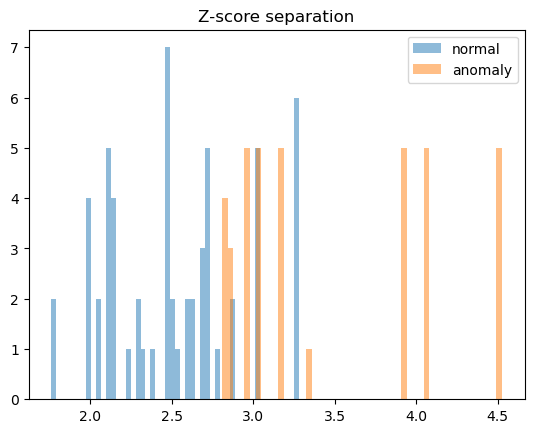

In [32]:
import matplotlib.pyplot as plt

plt.hist(val_scores[y_val_w == 0], bins=50, alpha=0.5, label="normal")
plt.hist(val_scores[y_val_w == 1], bins=50, alpha=0.5, label="anomaly")
plt.legend()
plt.title("Z-score separation")
plt.show()

In [35]:
# MAybe try gaussian

In [36]:
# single gauusian
import numpy as np
from scipy.stats import multivariate_normal

# X_train_model: (n_w, w * N)
# X_val_model:   (n_w_val, w * N)

mu = X_train_model.mean(axis=0)
cov = np.cov(X_train_model, rowvar=False)

# Numerical stability
cov += 1e-6 * np.eye(cov.shape[0])

model = multivariate_normal(
    mean=mu,
    cov=cov,
    allow_singular=False,
)

# Higher = more anomalous
def gaussian_scores(X):
    log_probs = model.logpdf(X)
    return -log_probs

# Validation scores: one score per window
val_scores = gaussian_scores(X_val_model)

In [38]:
metrics = evaluator.evaluate(
    scores=val_scores,
    y_true=y_val_w,
    predictions=val_pred,
)
metrics

{'mean_score': 194.62570319493202,
 'auc': 0.9038112522686026,
 'pr_auc': 0.8881406029242697,
 'precision': 0.7027027027027027,
 'recall': 0.6842105263157895,
 'f1': 0.6933333333333334,
 'tn': 47,
 'fp': 11,
 'fn': 12,
 'tp': 26}

In [41]:
from sklearn.mixture import GaussianMixture

# X_train_model: (n_w, w * N)
# X_val_model:   (n_w_val, w * N)

gmm = GaussianMixture(
    n_components=4,
    covariance_type="full",
    random_state=42,
)

gmm.fit(X_train_model)

# Higher score = more anomalous
val_scores = -gmm.score_samples(X_val_model)

In [42]:
metrics = evaluator.evaluate(
    scores=val_scores,
    y_true=y_val_w,
    predictions=val_pred,
)
metrics

{'mean_score': 198.5072955203087,
 'auc': 0.8752268602540834,
 'pr_auc': 0.8677090239120513,
 'precision': 0.7027027027027027,
 'recall': 0.6842105263157895,
 'f1': 0.6933333333333334,
 'tn': 47,
 'fp': 11,
 'fn': 12,
 'tp': 26}